# 22 -- N=2, N=3, N=64: sledgehamr vs surrogate reconstruction

Compares the sledgehamr 3+1D ground truth against the 1+1D BubbleMaster
surrogate reconstruction (collision weights x the `gs1-*` production
runtime scans) for two, three, and sixty-four colliding bubbles, at
$\bar\lambda=0.84$ and $\bar\lambda=0.069$.

In [1]:
from pathlib import Path
import subprocess
import tempfile
import os

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams

import ptbuilder as pt
from ptbuilder.analysis import (
    load_scan, load_scan_manifest, load_weights, reconstruct_pair_spectrum,
    build_runtime_scan_interpolator, to_chw, apply_keffsq, write_weights_input,
)
from ptbuilder.sledgehamr import (
    load_output, get_gw_spectrum, get_spectrum_interpolated_at_time,
)
from ptbuilder.weight_scan_diagnostics import load_kinematics
from ptbuilder.ic import _cutoff_times

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

REPO_ROOT   = Path(pt.__file__).parent.parent
DATA_DIR    = REPO_ROOT / 'data'
SH_RUNS_DIR = REPO_ROOT / 'sledgehamr_runs'
PLOTS_DIR   = REPO_ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

RECON_KR_MIN, RECON_KR_MAX = 1., 100.   # every scan's guaranteed kR_* coverage


class AveragedOutput:
    """Wraps two sledgehamr Output objects with identical snapshot times,
    exposing the same interface (GetTimesOfGravitationalWaveSpectra,
    GetGravitationalWaveSpectrum) but returning the mean of their two raw
    'Spectrum' arrays at each snapshot -- a drop-in replacement usable
    anywhere a plain Output is."""
    def __init__(self, out_a, out_b):
        self._a, self._b = out_a, out_b

    def GetTimesOfGravitationalWaveSpectra(self):
        return self._a.GetTimesOfGravitationalWaveSpectra()

    def GetGravitationalWaveSpectrum(self, idx):
        da = self._a.GetGravitationalWaveSpectrum(idx)
        db = self._b.GetGravitationalWaveSpectrum(idx)
        assert abs(da['t'] - db['t']) < 1e-6, (da['t'], db['t'])
        return {'t': da['t'], 'k_sq': da['k_sq'],
               'spectrum': 0.5 * (da['spectrum'] + db['spectrum'])}


def load_averaged_output(path, secondary_subdir='gw_spec_u_times_k'):
    """Load a sledgehamr run's primary (gw_spectra) and a sibling secondary
    spectrum folder (e.g. gw_spec_u_times_k) as one AveragedOutput. The
    secondary folder is exposed to pySledgehamr's Output loader via a
    symlink named 'gw_spectra' in a temp dir, since Output hardcodes that
    subdirectory name."""
    path = Path(path)
    out_a = load_output(str(path))
    tmpdir = Path(tempfile.mkdtemp())
    os.symlink((path / secondary_subdir).resolve(), tmpdir / 'gw_spectra')
    out_b = load_output(str(tmpdir))
    return AveragedOutput(out_a, out_b)


# Which collision weights the surrogate uses (set via the NB22_VARIANT environment
# variable; unset = the original figure):
#   ''          : original weights (textbook wall radius)
#   '_rnum'     : numerical wall radius (weights binary --wall-radius)
#   '_rnum_pf'  : + patch-fraction damping, handoff gamma=4 calibration
#   '_rnum_pfm' : + patch-fraction damping, measured-wall gamma-dependent calibration
VARIANT = os.environ.get('NB22_VARIANT', '')
PLOT_SUFFIX = {'': '', '_rnum': '_rnum', '_rnum_pf': '_rnum_patchfraction',
               '_rnum_pfm': '_rnum_patchfraction_measured'}[VARIANT]
# the measured-calibration figure uses the N_b=512 weights run out to the scan end (t=146)
N512_BASE, N512_NT, N512_TMAX = (('N512_lb084_g4_t146', 1500, 146.) if VARIANT == '_rnum_pfm'
                                 else ('N512_lb084_g4', 1024, 100.))

In [2]:
# Build any missing weights for the chosen variant from the tracked weights inputs:
# the weights binary with --wall-radius (needs cpp/weights/weights built), then for
# _rnum_pf / _rnum_pfm the patch-fraction damping (ptbuilder.patch_fraction).
from ptbuilder.patch_fraction import load_response, load_gamma_response, damped_weights
import shutil

WEIGHTS_BASES = {  # base name -> lambda_bar (scan, wall-radius table and calibration family)
    **{f'N3_084_{p}': 0.84 for p in ('pair_0_1', 'pair_0_2', 'pair_1_2', '3b')},
    **{f'N3_069_{p}': 0.069 for p in ('pair_0_1', 'pair_0_2', 'pair_1_2', '3b')},
    'N64_lb084_correct': 0.84, 'N64_lb069_v4': 0.069, 'N48_lb069_g6': 0.069, N512_BASE: 0.84,
}


def make_variant_weights(base, lb, variant, out_dir=DATA_DIR):
    win = DATA_DIR / f'weights_in_{base}.h5'
    rnum = Path(out_dir) / f'weights_out_{base}_rnum.h5'
    if not rnum.exists():
        subprocess.run([str(REPO_ROOT / 'cpp/weights/weights'), str(win), str(rnum),
                        '--wall-radius', str(DATA_DIR / f'wall_radius/lb{lb}.h5')],
                       check=True, capture_output=True)
    if variant == '_rnum':
        return
    with h5py.File(win) as f:
        t = f['t'][:]
    w, pi, pj, g = load_weights(rnum, len(t))
    prof = pt.PhysicsModel(pt.Phi4Potential(lb), pt.Config()).instanton
    if variant == '_rnum_pf':
        kern = load_response(lb, 'fixed_annulus', 2, 'zero')
        note = 'fixed_annulus, alpha=2, tail=zero, gamma4 calibration'
    else:
        kern = load_gamma_response(DATA_DIR / 'patch_fraction_calibration_measured.json', lb,
                                   'fixed_annulus', 2, 'zero')
        note = 'measured-wall calibration, gamma-interpolated, fixed_annulus, alpha=2, tail=zero'
    weff, _ = damped_weights(w, t, g, prof, kern)
    dst = Path(out_dir) / f'weights_out_{base}{variant}.h5'
    shutil.copy(rnum, dst)
    with h5py.File(dst, 'r+') as o:
        o['weights'][...] = weff.ravel()
        o.attrs['patch_fraction'] = note


if VARIANT:
    for base, lb in WEIGHTS_BASES.items():
        if not (DATA_DIR / f'weights_out_{base}{VARIANT}.h5').exists():
            make_variant_weights(base, lb, VARIANT)
            print(f'built weights_out_{base}{VARIANT}.h5')

## 1. N=2 / N=3 setup

Both pull from the same two 3-bubble sledgehamr realizations: N=2 takes
each of the 3 pairwise sub-collisions in isolation, N=3 is the full trio.

In [3]:
pos_084 = np.array([[72.25, 89.92, 100.],
                    [127.8, 89.92, 100.],
                    [108.7, 110.1, 100.]])
pos_069 = np.array([[16.23, 19.06, 22.5],
                    [28.77, 19.06, 22.5],
                    [24.08, 25.94, 22.5]])

CASES = {
    0.84: dict(
        # using the new "_nocutoff" sledgehamr runs -- (A+B)/2 averaged
        # with each run's own gw_spec_u_times_k output folder -- in place
        # of the originals. zero_pad=1 to match these runs' own grids
        # (verified from their HDF5 Headers).
        positions=pos_084, L=200., zero_pad=1., n_weights=500, t_scan_max=70.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_1__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_084_pair_0_1{VARIANT}.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_2__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_084_pair_0_2{VARIANT}.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_234_1_2__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_084_pair_1_2{VARIANT}.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_234_0_1_2_nocutoff',
        weights_out_3b=DATA_DIR / f'weights_out_N3_084_3b{VARIANT}.h5',
        scan_dir=DATA_DIR / 'runtime_scan_lb0.84_gs1-7_kR1-100_nw32',
        scan_loader=load_scan,
    ),
    0.069: dict(
        # using the new "_nocutoff" sledgehamr runs -- (A+B)/2 averaged
        # with each run's own gw_spec_u_times_k output folder -- in place
        # of the originals. zero_pad=1 to match these runs' own grids
        # (verified from their HDF5 Headers).
        positions=pos_069, L=50., zero_pad=1., n_weights=500, t_scan_max=30.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_1__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_069_pair_0_1{VARIANT}.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_2__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_069_pair_0_2{VARIANT}.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_1_2__nocutoff',
                 weights_out=DATA_DIR / f'weights_out_N3_069_pair_1_2{VARIANT}.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_456_0_1_2_nocutoff',
        weights_out_3b=DATA_DIR / f'weights_out_N3_069_3b{VARIANT}.h5',
        scan_dir=DATA_DIR / 'runtime_scan_lb0.069_gs1-11_kR1-100_nw32',
        scan_loader=load_scan_manifest,
    ),
}

for lb, case in CASES.items():
    case['weights_times'] = np.linspace(1., case['t_scan_max'], case['n_weights'])
    L, pos = case['L'], case['positions']
    dists = []
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        dists.append(np.linalg.norm(dp))
    case['Rstar_3b'] = float(np.mean(dists))   # trio's own characteristic R_*
    case['scan'] = case['scan_loader'](case['scan_dir'])
    omega_min = case['scan'].rows[0].wlist[0]
    omega_max = max(r.wlist[-1] for r in case['scan'].rows)
    case['k_out'] = np.geomspace(omega_min, omega_max, 128)
    case['interp_fn'], case['gammas'] = build_runtime_scan_interpolator(case['scan'], case['k_out'])
    case['times_bounds'] = np.array([min(r.times[0] for r in case['scan'].rows), case['scan'].t_max])

Loaded scan runtime_scan_lb0.84_gs1-7_kR1-100_nw32: 43 rows, gamma_ij in [1.000, 17.500], T_MAX=145.617


Loaded scan runtime_scan_lb0.069_gs1-11_kR1-100_nw32: 68 rows, gamma_ij in [1.000, 27.500], T_MAX=34.557


In [4]:
pair_w       = {}   # (lb, idx) -> (n_found, n_weights) weight arrays, all
                    # periodic images found for this pair (only the direct
                    # one is ever active by t_m -- see reconstruction below)
pair_gam     = {}   # (lb, idx) -> (n_found,) gamma per found image
pair_gamma   = {}   # (lb, idx) -> gamma of the direct image (smallest, for labels)
pair_d       = {}   # (lb, idx) -> centre-to-centre separation
pair_tm      = {}   # (lb, idx) -> BM comparison time t_m
trio_weights = {}   # lb -> dict(weights, pair_i, pair_j, gammas)
sh_output    = {}   # (lb, idx-or-'3b') -> pySledgehamr Output

for lb, case in CASES.items():
    n_wt = len(case['weights_times'])
    L, pos = case['L'], case['positions']

    for pair in case['pairs']:
        i, j = pair['idx']
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        d = float(np.linalg.norm(dp))
        t_m = float(_cutoff_times(d, 0, 1.)[2])

        w, pi, pj, gam = load_weights(pair['weights_out'], n_wt)
        pair_d[(lb, pair['idx'])]       = d
        pair_tm[(lb, pair['idx'])]      = t_m
        pair_w[(lb, pair['idx'])]       = w
        pair_gam[(lb, pair['idx'])]     = gam
        pair_gamma[(lb, pair['idx'])]   = float(gam.min())
        # both lb now use the (A+B)/2-averaged "_nocutoff" sledgehamr outputs.
        sh_output[(lb, pair['idx'])]    = load_averaged_output(pair['sh_path'])

    w, pi, pj, gam = load_weights(case['weights_out_3b'], n_wt)
    trio_weights[lb] = dict(weights=w, pair_i=pi.astype(int), pair_j=pj.astype(int), gammas=gam)
    sh_output[(lb, '3b')] = load_averaged_output(case['sh_path_3b'])
    case['t_m_3b'] = max(pair_tm[(lb, p['idx'])] for p in case['pairs'])

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 41
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 41
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 41
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxe

## 2. N=64 setup

In [5]:
# lb=0.84: bubble positions from the Cutting-style placement file
# (matches the CHW Fig. 8 benchmark point, gamma_*=3.94, L=225.28 --
# lambda_bar=0.84 kinematics/scan used as the established approximation to
# this file's own lambda_bar=0.845), weights computed locally (mid-radius).
CUTTING_H5_084 = SH_RUNS_DIR / 'Cutting_lb0.845_N64_g3.94.h5'
with h5py.File(CUTTING_H5_084, 'r') as f:
    hdr084 = f['Header'][:]
    bubbles64 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L64        = float(hdr084[1])
ZERO_PAD64 = 1.
Rstar64    = (L64 ** 3 / len(bubbles64)) ** (1. / 3.)

WEIGHTS_IN_084  = DATA_DIR / 'weights_in_N64_lb084_correct.h5'
WEIGHTS_OUT_084 = DATA_DIR / f'weights_out_N64_lb084_correct{VARIANT}.h5'
N_WEIGHTS_084   = 1024
T_SCAN_MAX_084  = 130.
weights_times64 = np.linspace(1., T_SCAN_MAX_084, N_WEIGHTS_084)

if not WEIGHTS_OUT_084.exists():
    kin_084 = load_kinematics(DATA_DIR / 'phi4_lambda_bar0.84' / 'instanton.h5')
    write_weights_input(path=WEIGHTS_IN_084, positions=bubbles64,
                        t=weights_times64, kinematics=kin_084,
                        L=L64, collision_radius='mid')
    weights_bin = REPO_ROOT / 'cpp/weights/weights'
    subprocess.run([str(weights_bin), str(WEIGHTS_IN_084), str(WEIGHTS_OUT_084)], check=True)

w64, pi64, pj64, gam64 = load_weights(WEIGHTS_OUT_084, n_t=N_WEIGHTS_084)
# "_long" supersedes the earlier short "leapfrog_2048" run (same grid --
# dimN_eff=2048, same placement file -- just run out much further in time,
# t<=450 vs t<=113), and is also the first lb=0.84/N=64 run with its own
# gw_spec_u_times_k output folder, so it additionally gets the same
# (A+B)/2-averaged treatment already applied to every other panel.
sh_out64 = load_output(SH_RUNS_DIR / 'Cutting_lb0.84_N64_g3.94_long')
sh_out64_avg = load_averaged_output(SH_RUNS_DIR / 'Cutting_lb0.84_N64_g3.94_long')
T1_64 = float(np.max(sh_out64.GetTimesOfGravitationalWaveSpectra()))
T2_64 = min(float(weights_times64[-1]), T1_64)

# lb=0.069: bubble positions from the Cutting-style placement file, weights
# already computed (mid-radius), sledgehamr run already computed. This
# case uses its own dedicated scan (finer time/gamma_ij resolution than
# gs1-6 above) -- its weights vanish well within that scan's shorter
# T_MAX, unlike the N=2/N=3 cases, which need gs1-6's longer T_MAX.
# the "long" sledgehamr run's trajectory closely matches the v4 realization
# (not the original placement) up through v4's own endpoint t=16.65 -- no
# separate initial-condition file exists to confirm this by position, but
# the integrated-power curves overlap almost exactly there while every
# other realization (orig/v2/v3) sits measurably apart -- so pair it with
# v4's own placement and weights.
CUTTING_H5_069 = SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00_v4.h5'
with h5py.File(CUTTING_H5_069, 'r') as f:
    hdr069 = f['Header'][:]
    bubbles64_069 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L64_069        = float(hdr069[1])
ZERO_PAD64_069 = 1.
Rstar64_069    = (L64_069 ** 3 / len(bubbles64_069)) ** (1. / 3.)

w64_069, pi64_069, pj64_069, gam64_069 = load_weights(
    DATA_DIR / f'weights_out_N64_lb069_v4{VARIANT}.h5', n_t=1024)
weights_times64_069 = np.linspace(1., 20., 1024)
sh_out64_069 = load_output(SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00_leapfrog_2048_long_v2')
# this run also has a second gw_spec_u_times_k output folder -- kept as a
# SEPARATE (A+B)/2-averaged curve alongside the original, not a
# replacement (see load_averaged_output above).
sh_out64_069_avg = load_averaged_output(SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00_leapfrog_2048_long_v2')
T1_069 = float(np.max(sh_out64_069.GetTimesOfGravitationalWaveSpectra()))
T2_069 = min(float(weights_times64_069[-1]), T1_069)

scan64_069 = load_scan_manifest(DATA_DIR / 'runtime_scan_lb0.069_gs1-11_kR1-100_nw32')
omega_min_069 = scan64_069.rows[0].wlist[0]
omega_max_069 = max(r.wlist[-1] for r in scan64_069.rows)
k_out64_069 = np.geomspace(omega_min_069, omega_max_069, 128)
interp_fn64_069, gammas64_069 = build_runtime_scan_interpolator(scan64_069, k_out64_069)
times_bounds64_069 = np.array([min(r.times[0] for r in scan64_069.rows), scan64_069.t_max])

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full b

Loaded scan runtime_scan_lb0.069_gs1-11_kR1-100_nw32: 68 rows, gamma_ij in [1.000, 27.500], T_MAX=34.557


In [6]:
# lb=0.069, N_b=48, gamma_*=6: a second, independent N=64-scale realization
# (fewer bubbles, higher gamma_*) plotted alongside the N_b=64 case in the
# same panel, using the SAME lb=0.069 scan/interpolator already built above
# (CASES[0.069]) -- gamma_ij for this realization tops out at 14.4, well
# inside that scan's gamma_ij<=27.5 coverage, so no separate scan is needed.
CUTTING_H5_N48 = SH_RUNS_DIR / 'Cutting_lb0.069_N48_g6.00.h5'
with h5py.File(CUTTING_H5_N48, 'r') as f:
    hdrN48 = f['Header'][:]
    bubblesN48 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L_N48        = float(hdrN48[1])
ZERO_PAD_N48 = 1.
Rstar_N48    = (L_N48 ** 3 / len(bubblesN48)) ** (1. / 3.)

w_N48, pi_N48, pj_N48, gam_N48 = load_weights(
    DATA_DIR / f'weights_out_N48_lb069_g6{VARIANT}.h5', n_t=1024)
weights_times_N48 = np.linspace(1., 40., 1024)
sh_out_N48_avg = load_averaged_output(SH_RUNS_DIR / 'Cutting_lb0.069_N48_g6.00')
T1_N48 = float(np.max(sh_out_N48_avg.GetTimesOfGravitationalWaveSpectra()))
T2_N48 = min(float(weights_times_N48[-1]), T1_N48)

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


In [7]:
# lb=0.84, N_b=512, gamma_*=4: a second, independent N=64-scale realization
# in the OTHER lambda_bar family (many more, but comparably-sized, bubbles),
# plotted alongside the N_b=64 case in the same panel. Reuses the SAME
# lb=0.84 scan/interpolator already built above (CASES[0.84]) -- gamma_ij
# for this realization tops out at 11.2, well inside that scan's
# gamma_ij<=17.5 coverage, so no separate scan is needed. The file's own
# stored lambda_bar is 0.8448 (not exactly 0.845/0.84) -- close enough that
# reusing the existing lb=0.84 kinematics/scan is the established
# approximation used throughout this notebook for this placement file.
CUTTING_H5_N512 = SH_RUNS_DIR / 'Cutting_lb0.845_N512_g4.00.h5'
with h5py.File(CUTTING_H5_N512, 'r') as f:
    hdrN512 = f['Header'][:]
    bubblesN512 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L_N512        = float(hdrN512[1])
ZERO_PAD_N512 = 1.
Rstar_N512    = (L_N512 ** 3 / len(bubblesN512)) ** (1. / 3.)

w_N512, pi_N512, pj_N512, gam_N512 = load_weights(
    DATA_DIR / f'weights_out_{N512_BASE}{VARIANT}.h5', n_t=N512_NT)
weights_times_N512 = np.linspace(1., N512_TMAX, N512_NT)
sh_out_N512_avg = load_averaged_output(SH_RUNS_DIR / 'Cutting_lb0.84_N512_g4.00')
T1_N512 = float(np.max(sh_out_N512_avg.GetTimesOfGravitationalWaveSpectra()))
T2_N512 = min(float(weights_times_N512[-1]), T1_N512)

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 116
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 116
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


## 3. Reconstructions

In [8]:
# N=2: reconstruct from the weights file the same way as N=3/N=64, summing
# every periodic image the weights binary found for this pair (direct,
# self-collision, or through the periodic boundary) -- at t_m only the
# direct image has started (weight nonzero), so this reduces to the direct
# pair's own contribution while also being correct if a pair's box ever
# were small enough for a periodic image to matter by t_m.
n2_results = {}   # (lb, idx) -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh)
for lb, case in CASES.items():
    for pair in case['pairs']:
        key = (lb, pair['idx'])
        d, t_m = pair_d[key], pair_tm[key]
        w, gam = pair_w[key], pair_gam[key]

        s = np.zeros(len(case['k_out']))
        for c in range(len(gam)):
            s += reconstruct_pair_spectrum(
                float(gam[c]), w[c], case['weights_times'], t_m,
                case['interp_fn'], case['times_bounds'], case['gammas'])
        y_recon = to_chw(s, d, lb, case['L'] ** 3)
        kR_recon = case['k_out'] * d
        valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
        kR_recon, y_recon = kR_recon[valid], y_recon[valid]

        k_sh, y_sh, t_act = get_spectrum_interpolated_at_time(
            sh_output[key], t_m, case['L'], case['zero_pad'])
        k_sh, y_sh = k_sh[1:], y_sh[1:]   # drop the k=0 mode
        r_sh = k_sh * (case['L'] * case['zero_pad']) / (2 * np.pi)
        n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
        yerr_sh = y_sh * np.sqrt(2. / n_modes)
        y_sh, yerr_sh = to_chw(y_sh, d, lb, case['L'] ** 3), \
                       to_chw(yerr_sh, d, lb, case['L'] ** 3)

        n2_results[key] = dict(kR_recon=kR_recon, y_recon=y_recon,
                               kR_sh=k_sh * d, y_sh=y_sh, yerr_sh=yerr_sh)

In [9]:
# N=3: trio-combined reconstruction (weights x scan, summed over the 3
# pairs). y converted to CHW units using the trio's own mean-separation R*.
n3_results = {}   # lb -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh)
for lb, case in CASES.items():
    wd = trio_weights[lb]
    k_out, Rstar_3b = case['k_out'], case['Rstar_3b']
    Leff = case['L'] * case['zero_pad']

    combined = np.zeros(len(k_out))
    for c_idx in range(len(wd['pair_i'])):
        combined += reconstruct_pair_spectrum(
            float(wd['gammas'][c_idx]), wd['weights'][c_idx], case['weights_times'],
            case['t_m_3b'], case['interp_fn'], case['times_bounds'], case['gammas'])
    combined = to_chw(combined, Rstar_3b, lb, case['L'] ** 3)

    kR_recon = k_out * Rstar_3b
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, combined = kR_recon[valid], combined[valid]

    k_sh, y_sh, t_act = get_spectrum_interpolated_at_time(
        sh_output[(lb, '3b')], case['t_m_3b'], case['L'], case['zero_pad'])
    k_sh, y_sh = k_sh[1:], y_sh[1:]
    r_sh = k_sh * Leff / (2 * np.pi)
    n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
    yerr_sh = y_sh * np.sqrt(2. / n_modes)
    y_sh, yerr_sh = to_chw(y_sh, Rstar_3b, lb, case['L'] ** 3), to_chw(yerr_sh, Rstar_3b, lb, case['L'] ** 3)

    n3_results[lb] = dict(kR_recon=kR_recon, y_recon=combined,
                          kR_sh=k_sh * Rstar_3b, y_sh=y_sh, yerr_sh=yerr_sh)

In [10]:
# N=64: trio-style reconstruction summed over all colliding pairs, per lb --
# sledgehamr late-time band (median + range from T_COLL_END to the last
# snapshot), using the (A+B)/2-averaged sledgehamr output exclusively (the
# plain "A"-only gw_spectra term is no longer plotted anywhere). The
# min/max half-widths are temporal variability (ringing during the
# late-time oscillation phase), not a statistical uncertainty; they widen
# at high k because the high-k tail sits closest to the numerical noise
# floor, so the same absolute ringing amplitude is a much larger relative
# swing there. The mode-counting statistical error (sqrt(2/N_modes), same
# as the N=2/N=3 bands) is added to each half-width in quadrature as an
# independent additional source of uncertainty.

def late_time_band(pi, w, gam, weights_times, sh_out, interp_fn, times_bounds, gammas, k_out, Rstar, L, zero_pad, lb, t_max):
    Leff = L * zero_pad
    recon = np.zeros(len(k_out))
    for p in range(len(pi)):
        recon += reconstruct_pair_spectrum(float(gam[p]), w[p], weights_times, t_max,
                                           interp_fn, times_bounds, gammas)
    recon = to_chw(recon, Rstar, lb, L ** 3)
    kR_recon = k_out * Rstar
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, recon = kR_recon[valid], recon[valid]

    sum_w = w.sum(axis=0)
    active = np.where(sum_w > 0.01)[0]
    t_coll_end = float(weights_times[active[-1]])
    times = np.array(sh_out.GetTimesOfGravitationalWaveSpectra())
    late_idx = np.where(times >= t_coll_end)[0]

    k_ref, spec_ref, _ = get_gw_spectrum(sh_out, int(late_idx[-1]), L, zero_pad)
    k_ref, spec_ref = k_ref[1:], spec_ref[1:]
    late_3d = []
    for idx in late_idx:
        k_late, y_late, _ = get_gw_spectrum(sh_out, int(idx), L, zero_pad)
        k_late, y_late = k_late[1:], y_late[1:]
        late_3d.append(np.interp(k_ref, k_late, y_late, left=np.nan, right=np.nan))
    late_3d = np.asarray(late_3d)
    late_median = to_chw(np.nanmedian(late_3d, axis=0), Rstar, lb, L ** 3)
    late_min    = to_chw(np.nanmin(late_3d, axis=0), Rstar, lb, L ** 3)
    late_max    = to_chw(np.nanmax(late_3d, axis=0), Rstar, lb, L ** 3)

    r_ref = k_ref * Leff / (2 * np.pi)
    n_modes = np.maximum(1., 4 * np.pi * r_ref ** 2)
    sigma_modes = late_median * np.sqrt(2. / n_modes)
    late_min = late_median - np.sqrt((late_median - late_min) ** 2 + sigma_modes ** 2)
    late_max = late_median + np.sqrt((late_max - late_median) ** 2 + sigma_modes ** 2)

    return dict(kR_recon=kR_recon, y_recon=recon, kR_sh=k_ref * Rstar,
               y_median=late_median, y_min=late_min, y_max=late_max,
               t_range=(times[late_idx[0]], times[late_idx[-1]]))


n64_results = {
    0.84: late_time_band(pi64, w64, gam64, weights_times64, sh_out64_avg,
                         CASES[0.84]['interp_fn'], CASES[0.84]['times_bounds'], CASES[0.84]['gammas'],
                         CASES[0.84]['k_out'], Rstar64, L64, ZERO_PAD64, 0.84, T2_64),
    0.069: late_time_band(pi64_069, w64_069, gam64_069, weights_times64_069, sh_out64_069_avg,
                          interp_fn64_069, times_bounds64_069, gammas64_069,
                          k_out64_069, Rstar64_069, L64_069, ZERO_PAD64_069,
                          0.069, T2_069),
}

# a second, independent lb=0.069 realization (N_b=48, gamma_*=6, fewer but
# higher-gamma bubbles) -- reuses the same lb=0.069 scan/interpolator
# (interp_fn64_069 etc.) already built for the N_b=64 case above, plotted
# ALONGSIDE it (not instead of) in the N_b=64 panel.
n64_results_N48 = late_time_band(
    pi_N48, w_N48, gam_N48, weights_times_N48, sh_out_N48_avg,
    interp_fn64_069, times_bounds64_069, gammas64_069,
    k_out64_069, Rstar_N48, L_N48, ZERO_PAD_N48, 0.069, T2_N48)

# a second, independent lb=0.84 realization (N_b=512, gamma_*=4, many more
# bubbles) -- reuses the same lb=0.84 scan/interpolator (CASES[0.84]) already
# built for the N_b=64 case above, plotted ALONGSIDE it (not instead of) in
# the N_b=64 panel.
n64_results_N512 = late_time_band(
    pi_N512, w_N512, gam_N512, weights_times_N512, sh_out_N512_avg,
    CASES[0.84]['interp_fn'], CASES[0.84]['times_bounds'], CASES[0.84]['gammas'],
    CASES[0.84]['k_out'], Rstar_N512, L_N512, ZERO_PAD_N512, 0.84, T2_N512)


## 4. Figure

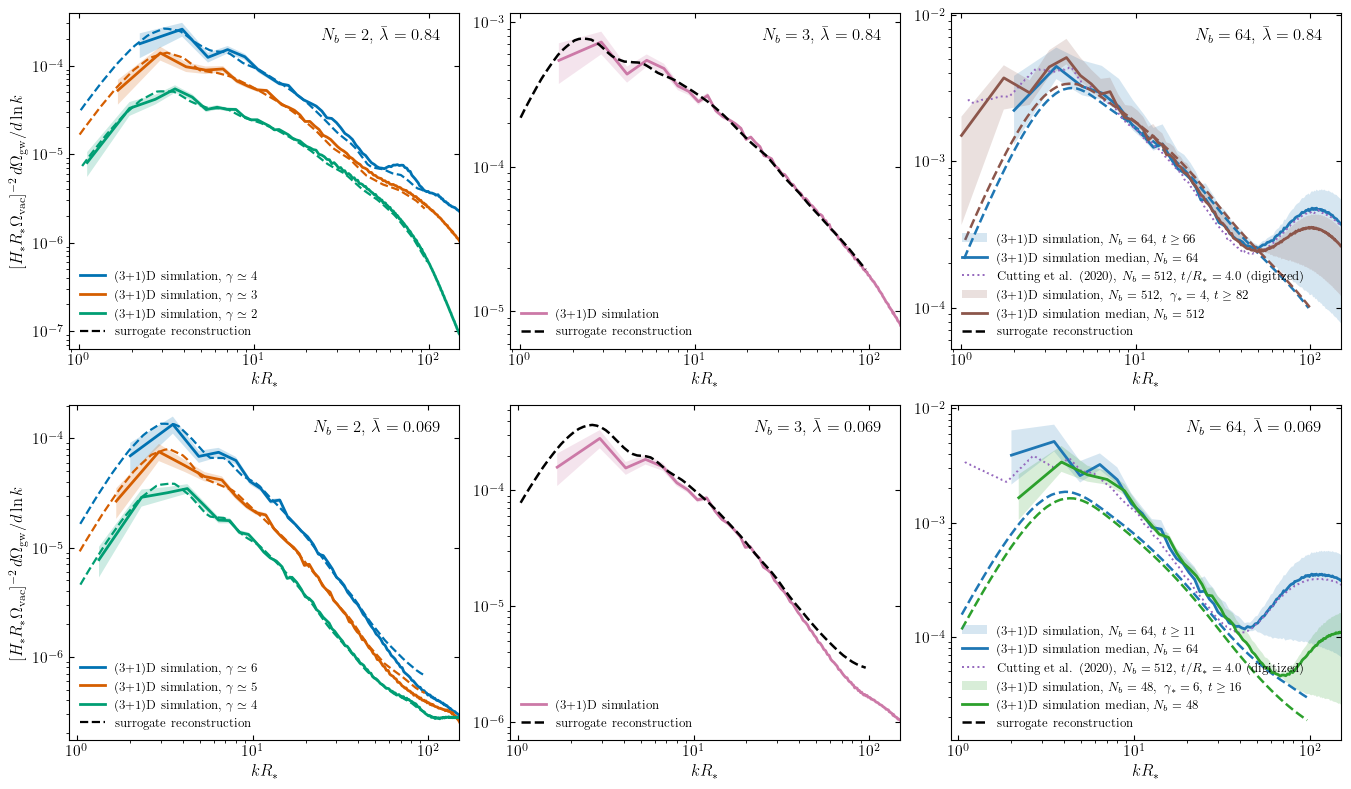

In [11]:
colors_pair = ['#0072B2', '#D55E00', '#009E73']
color_3b    = '#CC79A7'
color_64    = 'C0'
color_N48   = 'tab:green'
color_N512  = 'tab:brown'
RECON_COLOR = 'black'
X_MAX = 150.

# Digitized Cutting, Escartin, Hindmarsh & Weir (arXiv:2005.13537) Fig. 10
# panel (d), t/R_*=4.0, N_b=512 (largest simulation for each lambda_bar),
# gamma_*=4.0. Extracted from the paper's PDF at 600dpi via per-column
# pixel-color tracking (see the Weir2005 txt file headers for the full
# extraction/calibration method -- x-axis calibrated from actual tick
# label positions, cross-checked against the paper's own k=2pi/R_* marker).
# Already in kR_*/CHW units, no conversion needed. Single snapshot only,
# no band -- added temporarily for a quick sanity check against the
# literature, not a permanent fixture of this figure.
CUTTING_LIT_DIR = (REPO_ROOT / 'reference_codes' / 'FirstOrder_GW' /
                   'collision_weights' / 'Weir2005')

cutting_lit = {}
for lb_key, fname_key in [(0.84, '0.845'), (0.069, '0.069')]:
    cutting_lit[lb_key] = np.loadtxt(
        CUTTING_LIT_DIR / f'fig10_gamma4_tR4.0_lb{fname_key}.txt', delimiter=',')


def visible_extent(*xy_pairs, x_min=None, x_max=X_MAX):
    ys, xmins = [], []
    for x, y in xy_pairs:
        mask = x <= x_max
        if x_min is not None:
            mask &= x >= x_min
        if mask.any():
            ys.append(y[mask])
            xmins.append(x[mask].min())
    ys = np.concatenate(ys)
    ys = ys[ys > 0]
    return min(xmins), ys.min(), ys.max()


def style_panel(ax, x_min, ymin, ymax, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min / 1.15, X_MAX)
    ax.set_ylim(ymin / 1.5, ymax * 1.5)
    ax.set_xlabel(r'$kR_*$', fontsize=12)
    ax.text(0.95, 0.96, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='lower left')
    ax.tick_params(axis='both', labelsize=11, top=True, right=True, direction='in')


fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, lb in enumerate([0.84, 0.069]):
    case = CASES[lb]

    ax = axes[row_idx, 0]
    extents = []
    for pair, color in zip(case['pairs'], colors_pair):
        r = n2_results[(lb, pair['idx'])]
        gamma = pair_gamma[(lb, pair['idx'])]
        ax.plot(r['kR_sh'], r['y_sh'], color=color, lw=2,
                label=rf'(3+1)D simulation, $\gamma\simeq{round(gamma)}$')
        ax.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr_sh'], 1e-300),
                        r['y_sh'] + r['yerr_sh'], color=color, alpha=0.2, linewidth=0)
        ax.plot(r['kR_recon'], r['y_recon'], color=color, lw=1.6, ls='--')
        extents.append(visible_extent((r['kR_sh'], r['y_sh']), (r['kR_recon'], r['y_recon'])))
    ax.plot([], [], color=RECON_COLOR, lw=1.6, ls='--', label='surrogate reconstruction')
    x_min = min(e[0] for e in extents)
    style_panel(ax, x_min, min(e[1] for e in extents), max(e[2] for e in extents),
               rf'$N_b=2$,  $\bar\lambda={lb}$')

    ax = axes[row_idx, 1]
    r3 = n3_results[lb]
    ax.plot(r3['kR_sh'], r3['y_sh'], color=color_3b, lw=2, label='(3+1)D simulation')
    ax.fill_between(r3['kR_sh'], np.maximum(r3['y_sh'] - r3['yerr_sh'], 1e-300),
                    r3['y_sh'] + r3['yerr_sh'], color=color_3b, alpha=0.2, linewidth=0)
    ax.plot(r3['kR_recon'], r3['y_recon'], color=RECON_COLOR, lw=1.8, ls='--',
            label='surrogate reconstruction')
    x_min, ymin, ymax = visible_extent((r3['kR_sh'], r3['y_sh']), (r3['kR_recon'], r3['y_recon']))
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=3$,  $\bar\lambda={lb}$')

    ax = axes[row_idx, 2]
    r64 = n64_results[lb]
    ax.fill_between(r64['kR_sh'], r64['y_min'], r64['y_max'],
                    color=color_64, alpha=0.18, linewidth=0,
                    label=rf'(3+1)D simulation, $N_b=64$, $t\geq{r64["t_range"][0]:.0f}$')
    ax.plot(r64['kR_sh'], r64['y_median'], color=color_64, lw=2,
            label='(3+1)D simulation median, $N_b=64$')
    # surrogate reconstruction lines are color-matched to their own dataset
    # (same convention as the N=2 panel) so multiple overlapping
    # reconstructions in the same panel stay distinguishable -- the single
    # black legend entry is just a generic "this linestyle means surrogate
    # reconstruction" swatch, same pattern as the N=2 panel.
    ax.plot(r64['kR_recon'], r64['y_recon'], color=color_64, lw=1.8, ls='--')
    extents64 = [visible_extent((r64['kR_sh'], r64['y_min']),
                                (r64['kR_sh'], r64['y_max']),
                                (r64['kR_recon'], r64['y_recon']))]

    # Cutting et al. (2020) digitized Fig. 10(d), t/R_*=4.0, N_b=512,
    # lambda_bar-matched -- single snapshot, no band.
    lit = cutting_lit[lb]
    ax.plot(lit[:, 0], lit[:, 1], color='tab:purple', lw=1.4, ls=':',
            label=r'Cutting et al. (2020), $N_b=512$, $t/R_*=4.0$ (digitized)')
    extents64.append(visible_extent((lit[:, 0], lit[:, 1])))

    if lb == 0.069:
        # second, independent realization: N_b=48, gamma_*=6 -- plotted
        # alongside the N_b=64 case, not instead of it.
        r48 = n64_results_N48
        ax.fill_between(r48['kR_sh'], r48['y_min'], r48['y_max'],
                        color=color_N48, alpha=0.18, linewidth=0,
                        label=rf'(3+1)D simulation, $N_b=48,\ \gamma_*=6$, $t\geq{r48["t_range"][0]:.0f}$')
        ax.plot(r48['kR_sh'], r48['y_median'], color=color_N48, lw=2,
                label='(3+1)D simulation median, $N_b=48$')
        ax.plot(r48['kR_recon'], r48['y_recon'], color=color_N48, lw=1.8, ls='--')
        extents64.append(visible_extent((r48['kR_sh'], r48['y_min']),
                                        (r48['kR_sh'], r48['y_max']),
                                        (r48['kR_recon'], r48['y_recon'])))

    if lb == 0.84:
        # second, independent realization: N_b=512, gamma_*=4 -- plotted
        # alongside the N_b=64 case, not instead of it.
        r512 = n64_results_N512
        ax.fill_between(r512['kR_sh'], r512['y_min'], r512['y_max'],
                        color=color_N512, alpha=0.18, linewidth=0,
                        label=rf'(3+1)D simulation, $N_b=512,\ \gamma_*=4$, $t\geq{r512["t_range"][0]:.0f}$')
        ax.plot(r512['kR_sh'], r512['y_median'], color=color_N512, lw=2,
                label='(3+1)D simulation median, $N_b=512$')
        ax.plot(r512['kR_recon'], r512['y_recon'], color=color_N512, lw=1.8, ls='--')
        extents64.append(visible_extent((r512['kR_sh'], r512['y_min']),
                                        (r512['kR_sh'], r512['y_max']),
                                        (r512['kR_recon'], r512['y_recon'])))

    ax.plot([], [], color=RECON_COLOR, lw=1.8, ls='--', label='surrogate reconstruction')

    x_min = min(e[0] for e in extents64)
    ymin = min(e[1] for e in extents64)
    ymax = max(e[2] for e in extents64)
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=64$,  $\bar\lambda={lb}$')

ylabel = r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$'
axes[0, 0].set_ylabel(ylabel, fontsize=12)
axes[1, 0].set_ylabel(ylabel, fontsize=12)

fig.tight_layout()
fig.savefig(PLOTS_DIR / f'n2n3n64_surrogate_grid{PLOT_SUFFIX}.pdf', bbox_inches='tight')
plt.show()

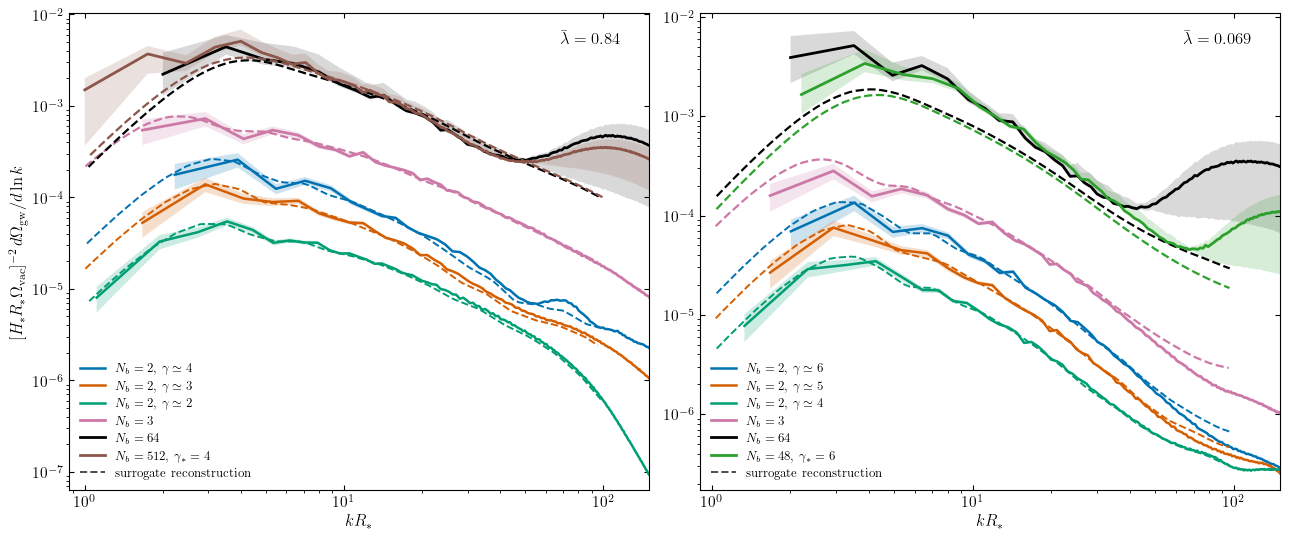

In [12]:
# --- Combined view: N=2/N=3/N=64 all on one panel per lambda_bar ---
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5.5))
color_64_combined = 'black'

for col_idx, lb in enumerate([0.84, 0.069]):
    ax = axes2[col_idx]
    case = CASES[lb]
    extents = []

    for pair, color in zip(case['pairs'], colors_pair):
        r = n2_results[(lb, pair['idx'])]
        gamma = pair_gamma[(lb, pair['idx'])]
        ax.plot(r['kR_sh'], r['y_sh'], color=color, lw=1.8,
                label=rf'$N_b=2$, $\gamma\simeq{round(gamma)}$')
        ax.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr_sh'], 1e-300),
                        r['y_sh'] + r['yerr_sh'], color=color, alpha=0.2, linewidth=0)
        ax.plot(r['kR_recon'], r['y_recon'], color=color, lw=1.4, ls='--')
        extents.append(visible_extent((r['kR_sh'], r['y_sh']), (r['kR_recon'], r['y_recon'])))

    r3 = n3_results[lb]
    ax.plot(r3['kR_sh'], r3['y_sh'], color=color_3b, lw=2, label=r'$N_b=3$')
    ax.fill_between(r3['kR_sh'], np.maximum(r3['y_sh'] - r3['yerr_sh'], 1e-300),
                    r3['y_sh'] + r3['yerr_sh'], color=color_3b, alpha=0.2, linewidth=0)
    ax.plot(r3['kR_recon'], r3['y_recon'], color=color_3b, lw=1.6, ls='--')
    extents.append(visible_extent((r3['kR_sh'], r3['y_sh']), (r3['kR_recon'], r3['y_recon'])))

    r64 = n64_results[lb]
    ax.fill_between(r64['kR_sh'], r64['y_min'], r64['y_max'],
                    color=color_64_combined, alpha=0.15, linewidth=0)
    ax.plot(r64['kR_sh'], r64['y_median'], color=color_64_combined, lw=2, label=r'$N_b=64$')
    ax.plot(r64['kR_recon'], r64['y_recon'], color=color_64_combined, lw=1.6, ls='--')
    extents.append(visible_extent((r64['kR_sh'], r64['y_min']), (r64['kR_sh'], r64['y_max']),
                                  (r64['kR_recon'], r64['y_recon'])))

    if lb == 0.069:
        # second, independent realization: N_b=48, gamma_*=6 -- alongside
        # the N_b=64 case, not instead of it.
        r48 = n64_results_N48
        ax.fill_between(r48['kR_sh'], r48['y_min'], r48['y_max'],
                        color=color_N48, alpha=0.18, linewidth=0)
        ax.plot(r48['kR_sh'], r48['y_median'], color=color_N48, lw=2,
                label=r'$N_b=48$, $\gamma_*=6$')
        ax.plot(r48['kR_recon'], r48['y_recon'], color=color_N48, lw=1.6, ls='--')
        extents.append(visible_extent((r48['kR_sh'], r48['y_min']),
                                      (r48['kR_sh'], r48['y_max']),
                                      (r48['kR_recon'], r48['y_recon'])))

    if lb == 0.84:
        # second, independent realization: N_b=512, gamma_*=4 -- alongside
        # the N_b=64 case, not instead of it.
        r512 = n64_results_N512
        ax.fill_between(r512['kR_sh'], r512['y_min'], r512['y_max'],
                        color=color_N512, alpha=0.18, linewidth=0)
        ax.plot(r512['kR_sh'], r512['y_median'], color=color_N512, lw=2,
                label=r'$N_b=512$, $\gamma_*=4$')
        ax.plot(r512['kR_recon'], r512['y_recon'], color=color_N512, lw=1.6, ls='--')
        extents.append(visible_extent((r512['kR_sh'], r512['y_min']),
                                      (r512['kR_sh'], r512['y_max']),
                                      (r512['kR_recon'], r512['y_recon'])))

    ax.plot([], [], color='0.3', lw=1.4, ls='--', label='surrogate reconstruction')
    x_min = min(e[0] for e in extents)
    style_panel(ax, x_min, min(e[1] for e in extents), max(e[2] for e in extents),
               rf'$\bar\lambda={lb}$')

axes2[0].set_ylabel(ylabel, fontsize=12)
fig2.tight_layout()
fig2.savefig(PLOTS_DIR / f'n2n3n64_surrogate_combined_2panel{PLOT_SUFFIX}.pdf', bbox_inches='tight')
plt.show()
